<a href="https://colab.research.google.com/github/zaima-sohail/Deep_learning_projects/blob/main/Image_classification_using_CNN_(CIFAR10_dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import tensorflow as tf
from tensorflow.keras import models, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Convolution2D, MaxPooling2D, Flatten

In [8]:
import matplotlib.pyplot as plt
import numpy as np

In [9]:
from keras.datasets import cifar10


In [10]:
(X_train,y_train),(X_test,y_test)=cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1549s 9us/step


In [11]:
X_train.shape

(50000, 32, 32, 3)

In [12]:
y_train=y_train.reshape(-1,)
y_train.shape
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [13]:
classes=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [14]:
def plot_sample(X,y,index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])


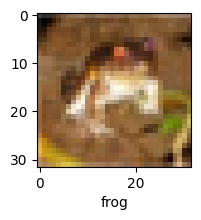

In [15]:
plot_sample(X_train,y_train,0)


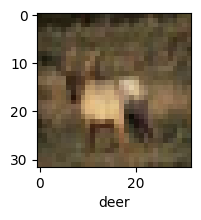

In [16]:
plot_sample(X_train,y_train,3)


In [17]:
X_train[0]/255

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [18]:
X_train=X_train/255
X_test=X_test/255

In [19]:
model=Sequential([
    Input(shape=(32,32,3))
])

In [20]:
model.add(Convolution2D(32,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Convolution2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [21]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [22]:
histroy=model.fit(X_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.4527 - loss: 1.5215 - val_accuracy: 0.5413 - val_loss: 1.2826
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.5916 - loss: 1.1646 - val_accuracy: 0.6084 - val_loss: 1.1151
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.6382 - loss: 1.0368 - val_accuracy: 0.6282 - val_loss: 1.0663
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.6651 - loss: 0.9589 - val_accuracy: 0.6581 - val_loss: 0.9872
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.6880 - loss: 0.8951 - val_accuracy: 0.6682 - val_loss: 0.9698
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.7087 - loss: 0.8435 - val_accuracy: 0.6669 - val_loss: 0.9578
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.7209 - loss: 0.7944 - val_accuracy: 0.6749 - val_loss: 0.9485
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.7376 -

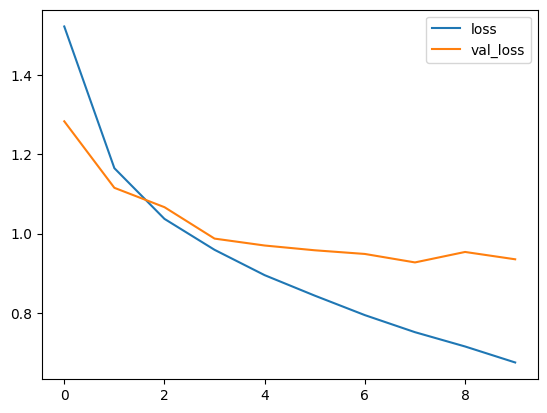

In [23]:
plt.plot(histroy.history['loss'],label='loss')
plt.plot(histroy.history['val_loss'],label='val_loss')
plt.legend()
plt.show()

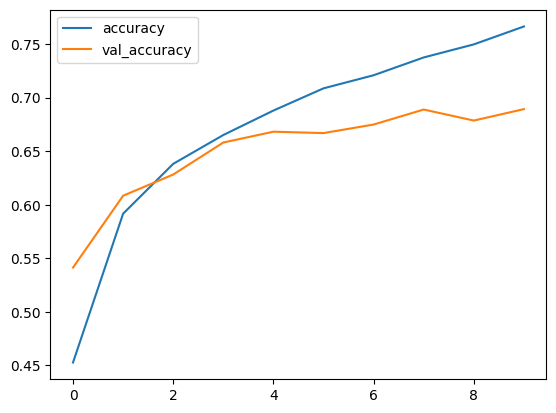

In [24]:
plt.plot(histroy.history['accuracy'],label='accuracy')
plt.plot(histroy.history['val_accuracy'],label='val_accuracy')
plt.legend()
plt.show()

In [26]:
model.evaluate(X_test,y_test.reshape(-1,))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6881 - loss: 0.9386


[0.9385803937911987, 0.6880999803543091]

In [27]:
y_test=y_test.reshape(-1,)

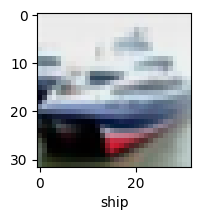

In [28]:
plot_sample(X_test,y_test,1)

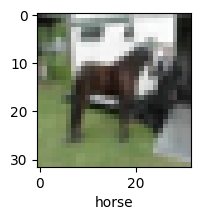

In [38]:
plot_sample(X_test,y_test,20)

In [30]:
y_pred=model.predict(X_test)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


array([[4.37698513e-03, 2.16144230e-02, 3.47499130e-03, ...,
        1.33493368e-03, 4.23187837e-02, 5.94707066e-03],
       [3.20052020e-02, 1.78622410e-01, 5.35847757e-05, ...,
        5.01954531e-08, 7.88882673e-01, 4.27941937e-04],
       [3.71879011e-01, 1.08504005e-01, 6.38558762e-03, ...,
        4.56892943e-04, 4.91129428e-01, 1.47960177e-02],
       ...,
       [1.63204706e-04, 1.40329983e-04, 1.48465022e-01, ...,
        6.48832247e-02, 6.66115258e-04, 7.09444284e-04],
       [2.25005329e-01, 4.46764141e-01, 2.80686263e-02, ...,
        7.41536263e-04, 2.28198594e-03, 9.59589495e-04],
       [4.18325499e-06, 1.72890680e-06, 3.10816773e-04, ...,
        9.82041836e-01, 1.43493901e-06, 1.65389156e-06]], dtype=float32)

In [33]:
np.argmax(y_pred[1])

np.int64(8)

In [31]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
import seaborn as sns

In [32]:
acc=accuracy_score(y_test,y_pred.argmax(axis=1))
acc

0.6881

### Confusion Matrix

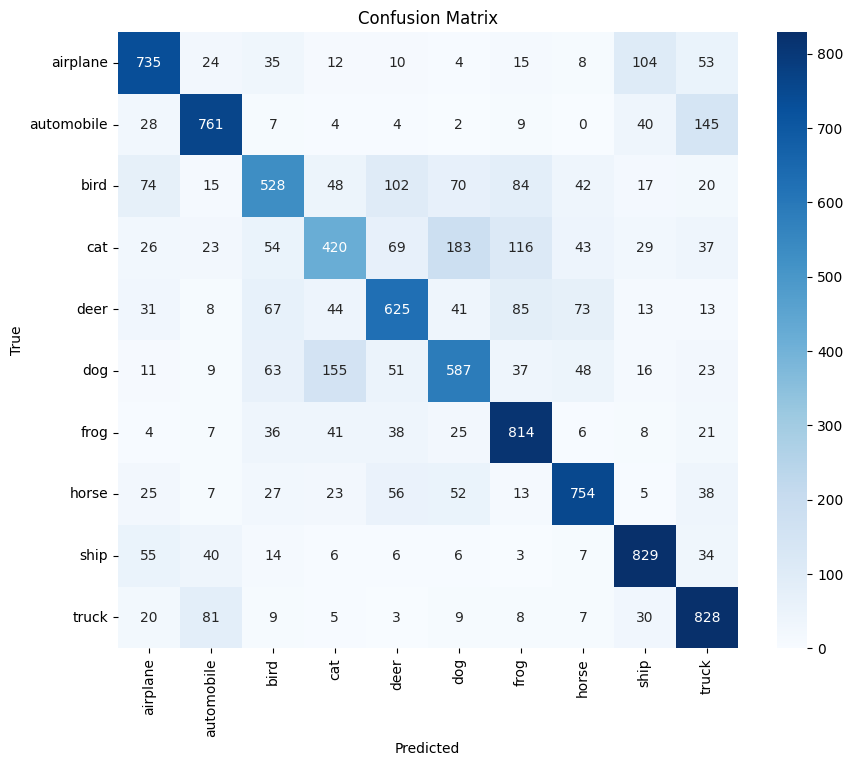

In [35]:
y_pred_classes = y_pred.argmax(axis=1)
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Classification Report

In [36]:
print(classification_report(y_test, y_pred_classes, target_names=classes))

              precision    recall  f1-score   support

    airplane       0.73      0.73      0.73      1000
  automobile       0.78      0.76      0.77      1000
        bird       0.63      0.53      0.57      1000
         cat       0.55      0.42      0.48      1000
        deer       0.65      0.62      0.64      1000
         dog       0.60      0.59      0.59      1000
        frog       0.69      0.81      0.75      1000
       horse       0.76      0.75      0.76      1000
        ship       0.76      0.83      0.79      1000
       truck       0.68      0.83      0.75      1000

    accuracy                           0.69     10000
   macro avg       0.68      0.69      0.68     10000
weighted avg       0.68      0.69      0.68     10000

